<a id="inicio"></a>

# Housing Price Analysis and Prediction — Part 1: Data Preparation & Exploration

## Objective

This project analyzes and predicts residential property prices using the Ames Housing dataset. The goal is to build accurate predictive models by combining thorough data preparation, feature engineering, and exploratory data analysis.

## Methodology

- **Data Preparation**: Feature type classification, ordinal encoding, and missing value imputation
- **Exploratory Analysis**: Correlation analysis, distribution inspection, and visualization of key relationships
- **Modeling** (Part 2): Ridge regression, Random Forest, KNN, SHAP explainability, PCA, t-SNE, and Gaussian Mixture


In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))

import numpy as np
import pandas as pd

%config InlineBackend.figure_format = 'retina'
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns;
sns.set()

<a id="indice"></a>
<h2><font color="#00586D" size=5>Table of Contents</font></h2>

#### <font color="#00586D"> Notebook I</font>
* [1. Introduction](#section1)
* [2. Data Preparation](#section2)
* [3. Preliminary Exploration](#section3)

#### <font color="#00586D"> Notebook II</font>
* [4. Prediction with Baseline Models](#section4)
* [5. Ensembles](#section5)
* [6. Explainability](#section6)
* [7. KNN](#section7)
* [8. Feature Engineering](#section8)
* [9. Outlier Removal](#section9)
* [10. Unsupervised Learning: PCA and EM](#section10)


---

<a id="section1"></a>
## <font color="#00586D"> 1. Introduction</font>
<br>

This project addresses a housing price analysis and prediction problem. The original dataset was obtained from [Kaggle](https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data), and serves as the basis for an ongoing competition. As described in the challenge, this problem is well-suited for feature engineering and ensemble methods. This project tackles these tasks, among others.

Although both a training set and a test set can be downloaded from the website, the test set is unlabeled. Therefore, only the training set with cross-validation will be used. An interesting extension would be to submit test predictions for comparison with other results. It is also worthwhile to review work that others have done with this same dataset, available on Kaggle.


The file `data/houses.csv` contains the data used in this project. As can be observed after an initial inspection, missing values are encoded with the label `NA`, although this point will be discussed in more detail later.

In [2]:
df_houses = pd.read_csv('data/houses.csv', index_col=0, na_values='NA')
#df_houses.info()
df_houses.sample(5)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
738,60,RL,72.0,10463,Pave,NaN,IR1,HLS,AllPub,CulDSac,...,0,NaN,NaN,NaN,0,6,2006,WD,Normal,239900
210,20,RL,75.0,8250,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,7,2008,WD,Normal,145000
1302,70,RL,NaN,7500,Pave,NaN,IR1,Bnk,AllPub,Inside,...,0,NaN,NaN,NaN,0,11,2009,WD,Normal,177500
578,80,RL,96.0,11777,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,5,2006,WD,Abnorml,164500
1356,80,RL,102.0,10192,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,GdPrv,NaN,0,9,2006,WD,Normal,170000


---

<a id="section2"></a>
## <font color="#00586D"> 2. Data Preparation</font>


### <font color="#00586D">Data Types</font>


The dataset represents each property using 80 features whose descriptions can be found in the file `data/data_description.txt`. This information is also useful for determining the appropriate data type for each feature and, in some cases, the possible values they can take.


<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i> This circumstance is of particular interest, as it greatly simplifies the transformation *pipeline*, allowing us to focus on building the models. However, to process the test data and submit results, a full *pipeline* would need to be built. That exercise is left as optional.
</div>


Although each feature is encoded with a specific data type, this may not correspond to how it should be treated. For example, the `MSSubClass` column represents the dwelling type using numerical values, yet it should be treated as discrete. On the other hand, there are discrete features whose possible values have an ordinal relationship, and it is not advisable to lose that information: these should be treated as ordinal (encoded with categories or integers).

In this cell, the different feature types are established and the ordinal value descriptions are defined. This inspection work (somewhat tedious) was carried out ***manually*** based on the descriptions provided in the file `data/data_description.txt` (it is recommended to take a look).

In [3]:
# Numerical features
numerical = ['LotFrontage', 'LotArea','OverallQual','OverallCond',
             'YearBuilt','YearRemodAdd','MasVnrArea','BsmtFinSF1','BsmtFinSF2',
             'BsmtUnfSF','TotalBsmtSF','1stFlrSF','2ndFlrSF','LowQualFinSF',
             'GrLivArea','BsmtFullBath','BsmtHalfBath','FullBath','HalfBath',
             'BedroomAbvGr','KitchenAbvGr','TotRmsAbvGrd','Fireplaces','GarageYrBlt',
             'GarageCars','GarageArea','WoodDeckSF','OpenPorchSF','EnclosedPorch',
             '3SsnPorch','ScreenPorch','PoolArea','MiscVal','MoSold','YrSold','SalePrice']

# Categorical features (discrete)
discrete = ['MSSubClass','MSZoning','Street','Alley','LandContour', 'LotConfig',
            'Neighborhood', 'Condition1', 'Condition2','BldgType','HouseStyle',
            'RoofStyle','RoofMatl','Exterior1st','Exterior2nd','MasVnrType',
            'Foundation','Heating','CentralAir','Electrical','GarageType','MiscFeature',
            'SaleType','SaleCondition']

# Categorical features (ordinal)
ordinal = ['LotShape','Utilities', 'LandSlope','ExterQual','ExterCond','BsmtQual',
           'BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2','HeatingQC',
           'KitchenQual','Functional','FireplaceQu','GarageFinish','GarageQual',
           'GarageCond','PavedDrive','PoolQC','Fence']

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i> For ordinal features, **it is important to preserve the order relationship of the labels**.
</div>


 This means that, regardless of how and where the encoding is performed, the order must be provided. In this case, the initial *DataFrame* will be re-encoded to simplify subsequent code.

In [4]:
df_houses['LotShape'] = df_houses['LotShape'].map({'IR3':1,'IR2':2,'IR1':3,'Reg':4})
df_houses['Utilities'] = df_houses['Utilities'].map({'ELO':1,'NoSeWa':2,'NoSewr':3,'AllPub':4})
df_houses['LandSlope'] = df_houses['LandSlope'].map({'Gtl':1,'Mod':2,'Sev':3})
df_houses['ExterQual'] = df_houses['ExterQual'].map({'Po':1, 'Fa':2,'TA':3, 'Gd':4, 'Ex':5})
df_houses['ExterCond'] = df_houses['ExterCond'].map({'Po':1, 'Fa':2,'TA':3, 'Gd':4, 'Ex':5})
df_houses['BsmtQual'] = df_houses['BsmtQual'].map({'Po':1, 'Fa':2,'TA':3, 'Gd':4, 'Ex':5})
df_houses['BsmtCond'] = df_houses['BsmtCond'].map({'Po':1, 'Fa':2,'TA':3, 'Gd':4, 'Ex':5})
df_houses['BsmtExposure'] = df_houses['BsmtExposure'].map({'No':1,'Mn':2,'Av':3, 'Gd':4})
df_houses['BsmtFinType1'] = df_houses['BsmtFinType1'].map({'Unf':1,'LwQ':2,'Rec':3, 'BLQ':4, 'ALQ':5, 'GLQ':6})
df_houses['BsmtFinType2'] = df_houses['BsmtFinType2'].map({'Unf':1,'LwQ':2,'Rec':3, 'BLQ':4, 'ALQ':5, 'GLQ':6})
df_houses['HeatingQC'] = df_houses['HeatingQC'].map({'Po':1, 'Fa':2,'TA':3, 'Gd':4, 'Ex':5})
df_houses['KitchenQual'] = df_houses['KitchenQual'].map({'Po':1, 'Fa':2,'TA':3, 'Gd':4, 'Ex':5})
df_houses['Functional'] = df_houses['Functional'].map({'Sal':1, 'Sev':2, 'Maj2':3, 'Maj1':4, 'Mod':5, 'Min2':6, 'Min1':7, 'Typ':8})
df_houses['FireplaceQu'] = df_houses['FireplaceQu'].map({'Po':1, 'Fa':2,'TA':3, 'Gd':4, 'Ex':5})
df_houses['GarageFinish'] = df_houses['GarageFinish'].map({'Unf':1,'RFn':2,'Fin':3})
df_houses['GarageQual'] = df_houses['GarageQual'].map({'Po':1, 'Fa':2,'TA':3, 'Gd':4, 'Ex':5})
df_houses['GarageCond'] = df_houses['GarageCond'].map({'Po':1, 'Fa':2,'TA':3, 'Gd':4, 'Ex':5})
df_houses['PavedDrive'] = df_houses['PavedDrive'].map({'N':1,'P':2,'Y':3})
df_houses['PoolQC'] = df_houses['PoolQC'].map({'Po':1, 'Fa':2,'TA':3, 'Gd':4, 'Ex':5})
df_houses['Fence'] = df_houses['Fence'].map({'MnWw':1,'GdWo':2,'MnPrv':3, 'GdPrv':4})

<div class="alert alert-block alert-warning">
    
<i class="fa fa-exclamation-circle" aria-hidden="true"></i>
__Important__: Although we have not yet performed the train/test split, we are ***not*** introducing encoding errors or *data leakage*, since these categories are predefined and, therefore, we **assume** that this is the format in which all data — including new data — would arrive.
</div>

---

### <font color="#00586D">Null Values</font>

Handling missing values in this dataset is particularly nuanced due to the different data types and the use of the `NA` value in the original file. Although an initial look at the dataset shows that it does not contain missing values as such, but rather the `NA` symbol (which has been treated as *NaN*), a closer look at the data types reveals that, for some features, `NA` **is informative**. For example, in the case of `PoolQC`, which represents pool quality and is the column with the most missing values, `NA` indicates that there is no pool and that `PoolArea` equals zero. Although we could discard the `PoolQC` column because `PoolArea` already provides information, we can encode it correctly so that the algorithms themselves determine whether the variable is relevant.

In order to handle null or missing values, we first examine the columns where these values exist.

In [5]:
missing_vals = df_houses.isna().sum().sort_values(ascending=False).where(lambda n: n>0).dropna()
missing_vals

PoolQC          1453.0
MiscFeature     1406.0
Alley           1369.0
Fence           1179.0
MasVnrType       872.0
FireplaceQu      690.0
LotFrontage      259.0
GarageYrBlt       81.0
GarageCond        81.0
GarageType        81.0
GarageFinish      81.0
GarageQual        81.0
BsmtExposure      38.0
BsmtFinType2      38.0
BsmtCond          37.0
BsmtQual          37.0
BsmtFinType1      37.0
MasVnrArea         8.0
Electrical         1.0
dtype: float64

Before proceeding to handle them, it is necessary to consider that the presence or absence of a value can provide useful information. The `missingno` library implements some utility functions for carrying out this inspection.

In [6]:
#!pip install missingno

import missingno as msno

The `msno.matrix()` function can be used to visualize the occurrence of missing values in the DataFrame. In this case, only the columns containing missing values will be displayed. Sometimes, sorting by a column can improve the visualization (in this case, not by much).

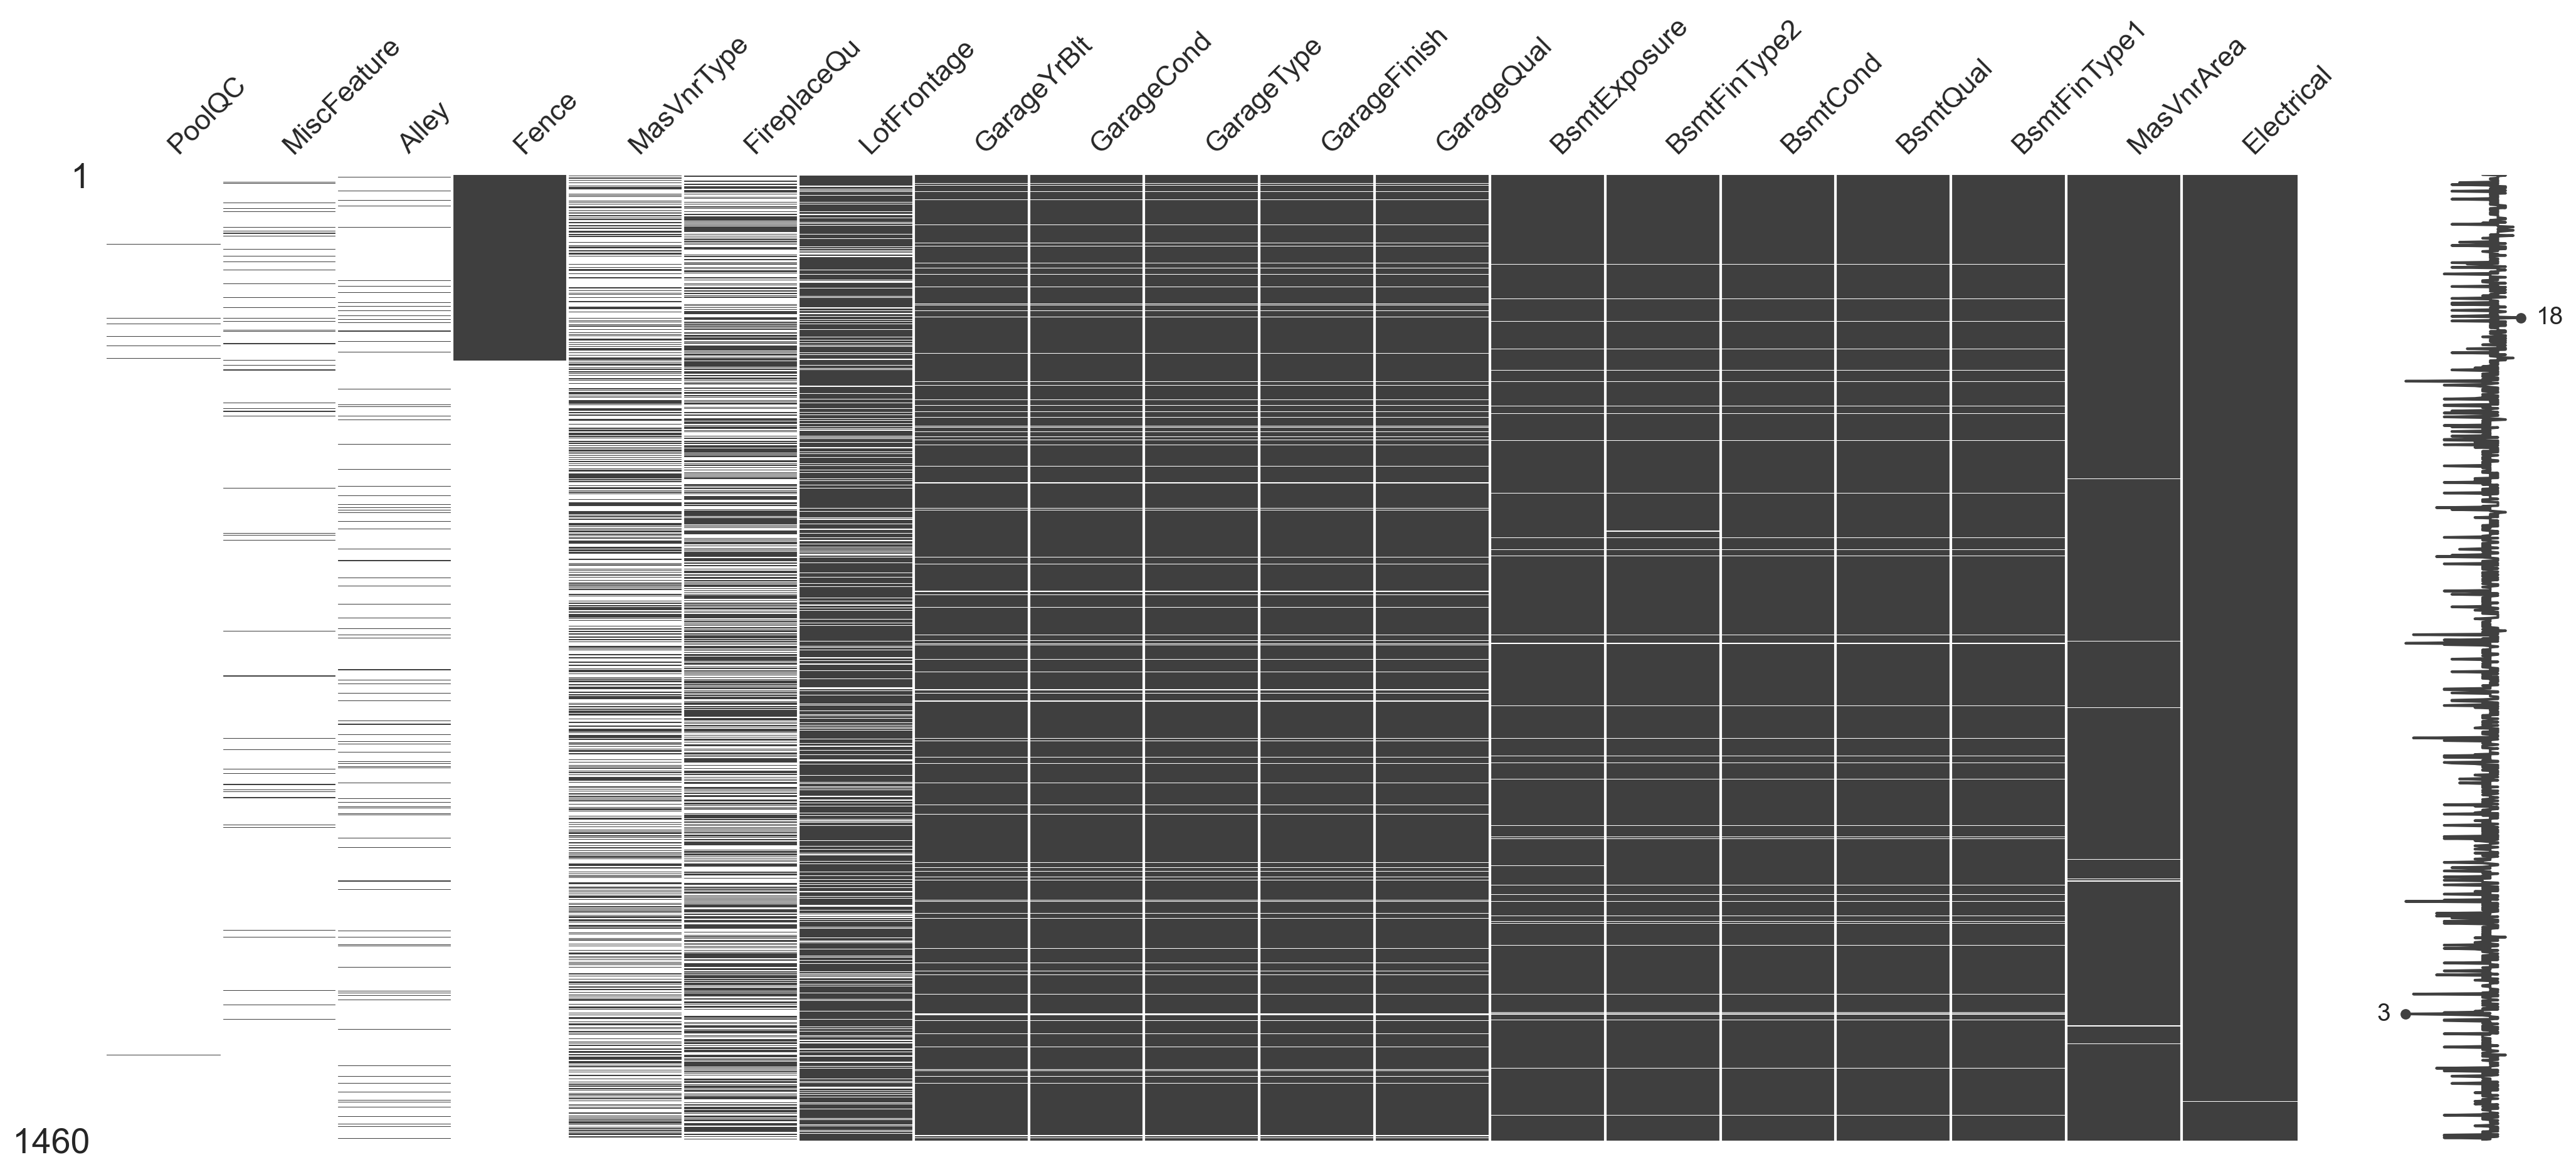

In [7]:
#msno.matrix(df_houses[missing_vals.index].sort_values(by='LotFrontage'))
msno.matrix(df_houses[missing_vals.index].sort_values(by='Fence'));

The chart shows that, as expected, there is a relationship in the occurrence of missing values for three groups of columns: those related to the garage, the basement, and the two masonry columns. The number of known values per row ranges between 4 and 18.

Another type of chart that can be useful in this context is a heatmap showing the correlation of the variables. In this case, the data is converted to binary values indicating whether the value is known or not, and the correlation of these values is calculated.

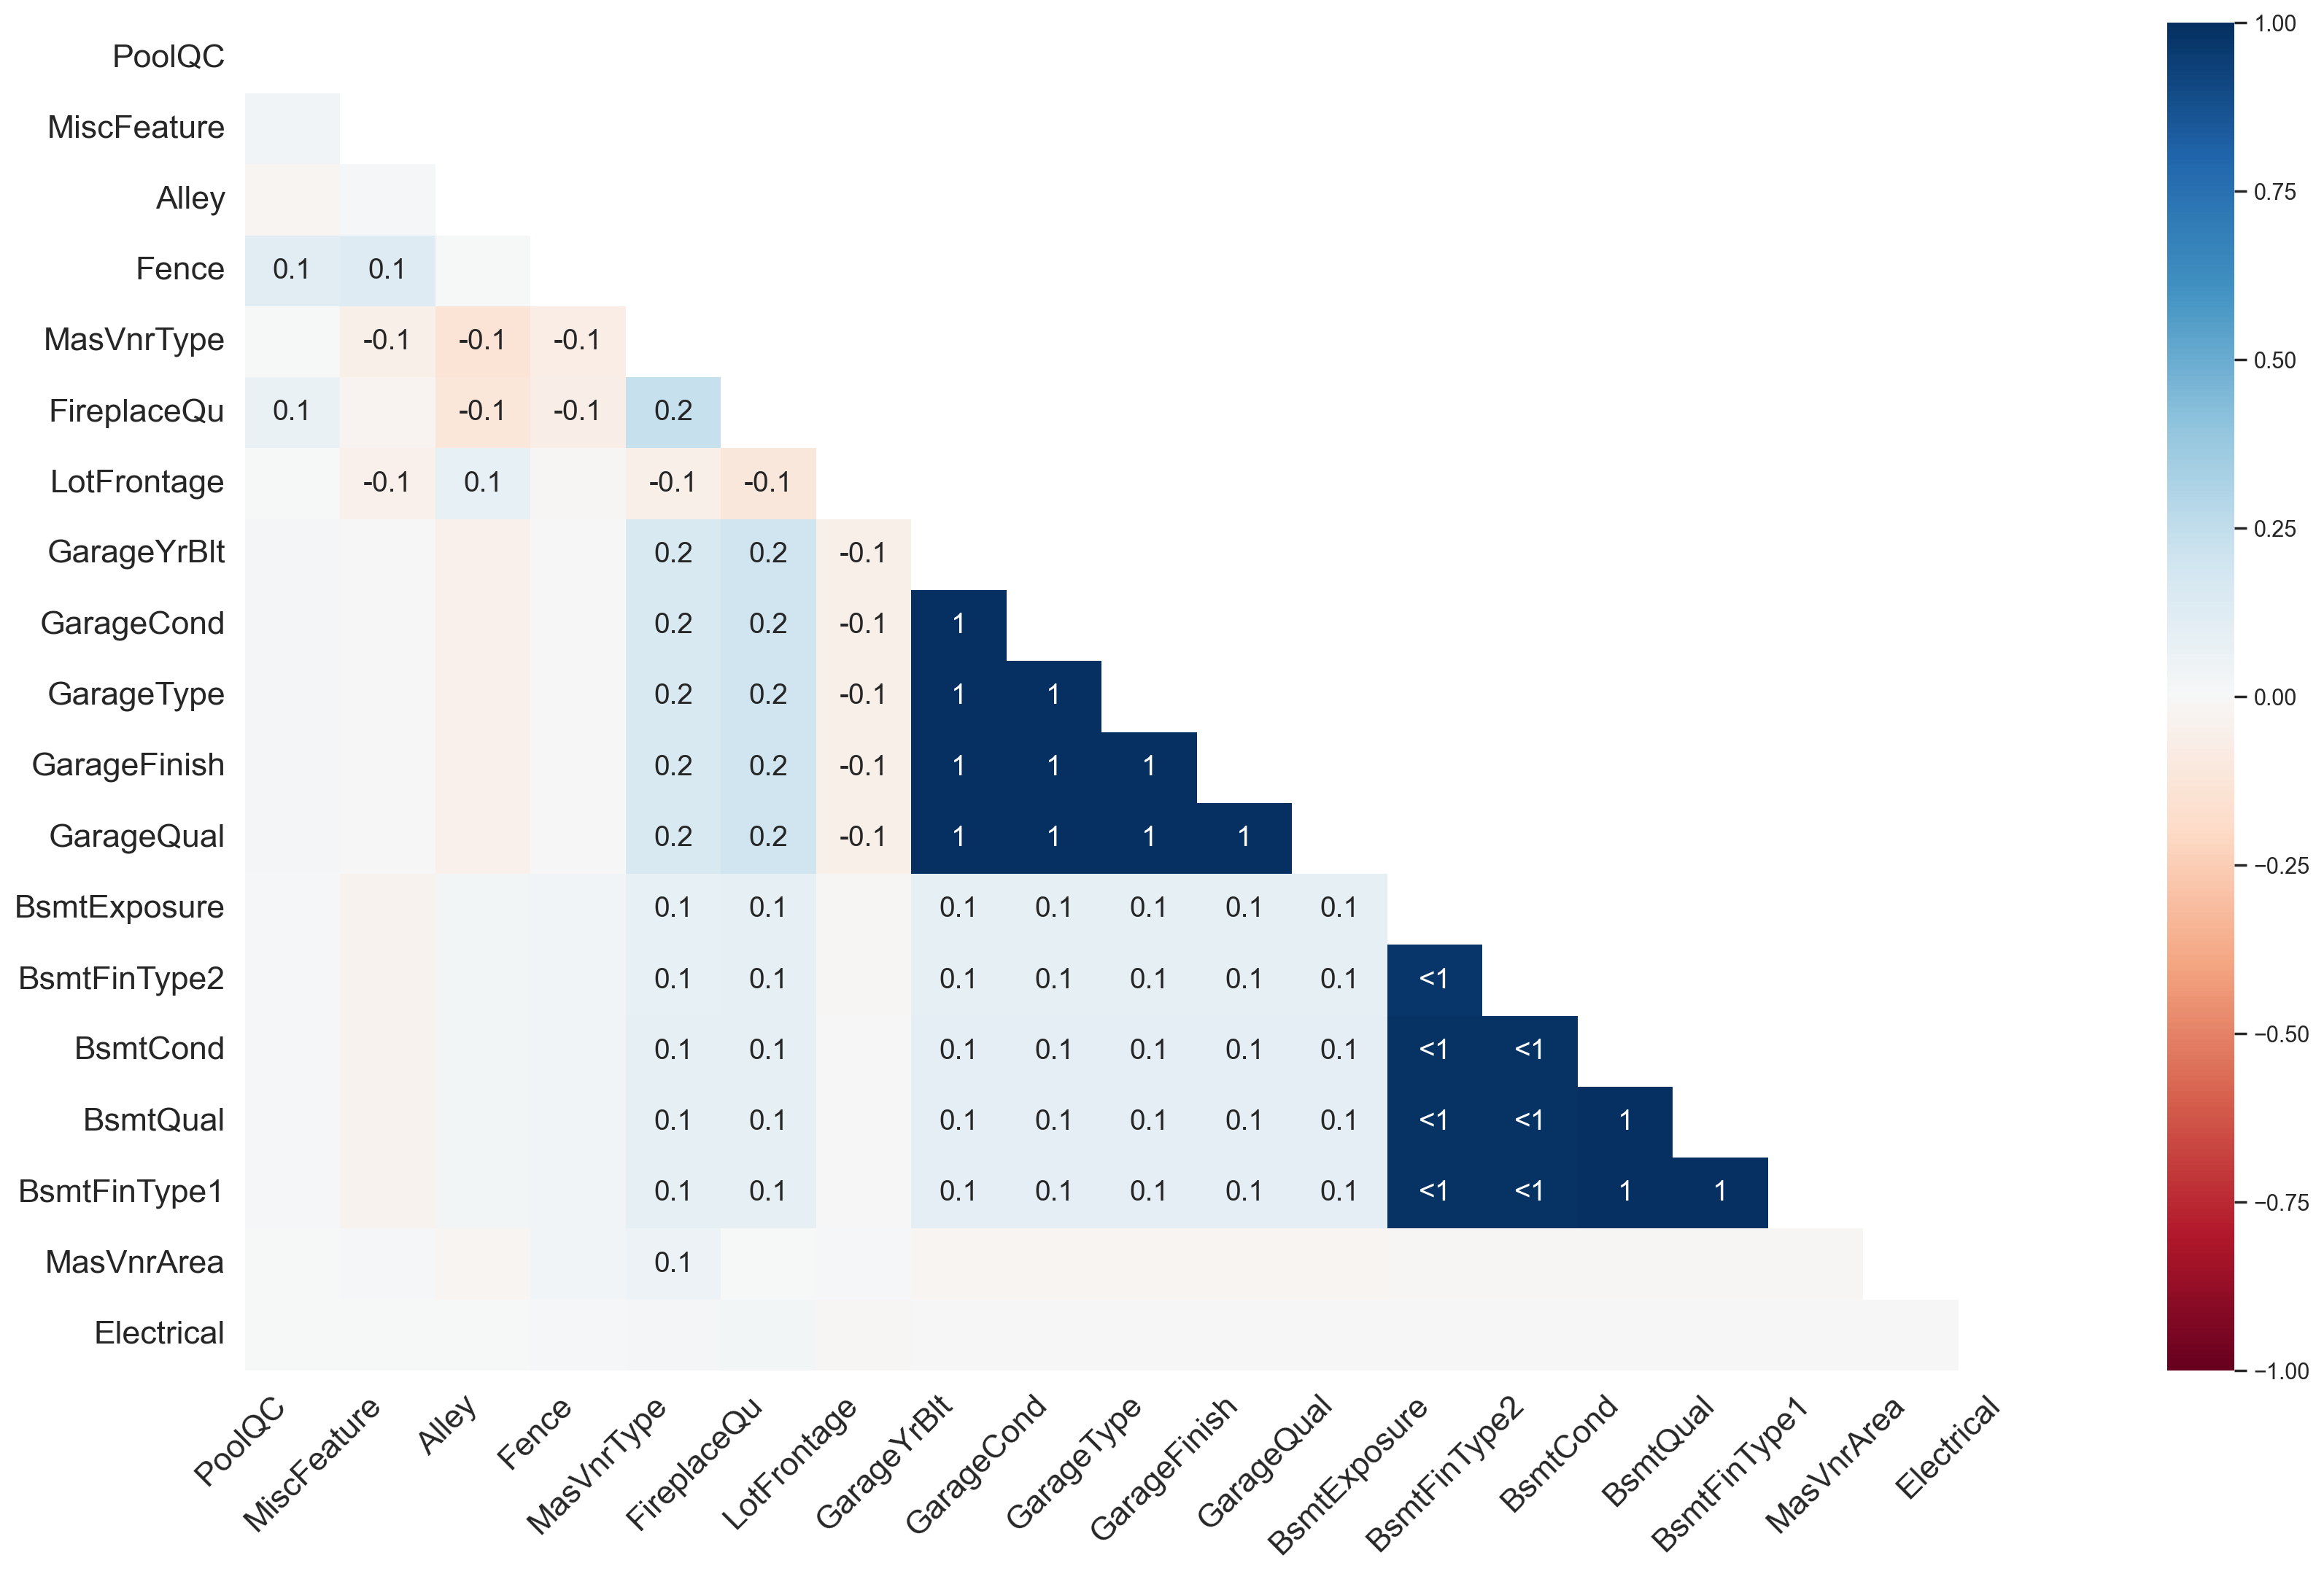

In [8]:
msno.heatmap(df_houses[missing_vals.index]);

The same pattern is observed as in the previous chart. Additionally, there is some correlation between the existence of a garage and a basement. There is also correlation between the existence of a fireplace and these two features.

There are 19 features with missing data. The treatment for each depends on its category. For example, for ordinal features, `NA` always represents the lowest category (according to the file `data/data_description.txt`). Therefore, it can be encoded as an additional category. Since the value $1$ was previously assigned to the lowest category, the value 0 can be imputed.

In [9]:
df_houses[ordinal] = df_houses[ordinal].fillna(0)
df_houses.isna().sum().sort_values(ascending=False).where(lambda n: n>0).dropna()

MiscFeature    1406.0
Alley          1369.0
MasVnrType      872.0
LotFrontage     259.0
GarageYrBlt      81.0
GarageType       81.0
MasVnrArea        8.0
Electrical        1.0
dtype: float64

For discrete columns, `NA` also constitutes a category that, in general, represents the **non-existence** of an element.

In [10]:
df_houses[discrete] = df_houses[discrete].fillna('None')
df_houses.isna().sum().sort_values(ascending=False).where(lambda n: n>0).dropna()

LotFrontage    259.0
GarageYrBlt     81.0
MasVnrArea       8.0
dtype: float64

After removing these values, three numerical columns with missing values remain. The first, `LotFrontage`, is special, as it could represent actual missing values or indicate that there is no street access. The description shows that there are no zero values among the known values.

In [11]:
df_houses['LotFrontage'].describe()

count    1201.000000
mean       70.049958
std        24.284752
min        21.000000
25%        59.000000
50%        69.000000
75%        80.000000
max       313.000000
Name: LotFrontage, dtype: float64

It is interesting to observe the values of some related columns in cases where `LotFrontage` is null.

In [12]:
df_houses[df_houses['LotFrontage'].isna()][['LotFrontage','LotArea','MSZoning','Street','Alley']].sort_values(by='LotArea', ascending=False)

,LotFrontage,LotArea,MSZoning,Street,Alley
Id,,,,,
336,NaN,164660,RL,Grvl,None
250,NaN,159000,RL,Pave,None
707,NaN,115149,RL,Pave,None
1397,NaN,57200,RL,Pave,None
458,NaN,53227,RL,Pave,None
...,...,...,...,...,...
976,NaN,2651,FV,Pave,None
181,NaN,2117,FV,Pave,None
1359,NaN,2117,FV,Pave,None


Nothing unusual is observed. It is also interesting to check whether any property corresponds to agricultural land (`MSZoning=A`).

In [13]:
df_houses[df_houses['LotFrontage'].isna()]['MSZoning'].value_counts()

MSZoning
RL    229
RM     19
FV      8
RH      3
Name: count, dtype: int64

We can see that relative values for `LotArea` (lot area) and street type do exist. This suggests that the best approach is to impute the missing value. A simple strategy is to use the median. However, one might expect some correlation between the lot area `LotArea` and the street frontage `LotFrontage`.

Correlation: 0.43


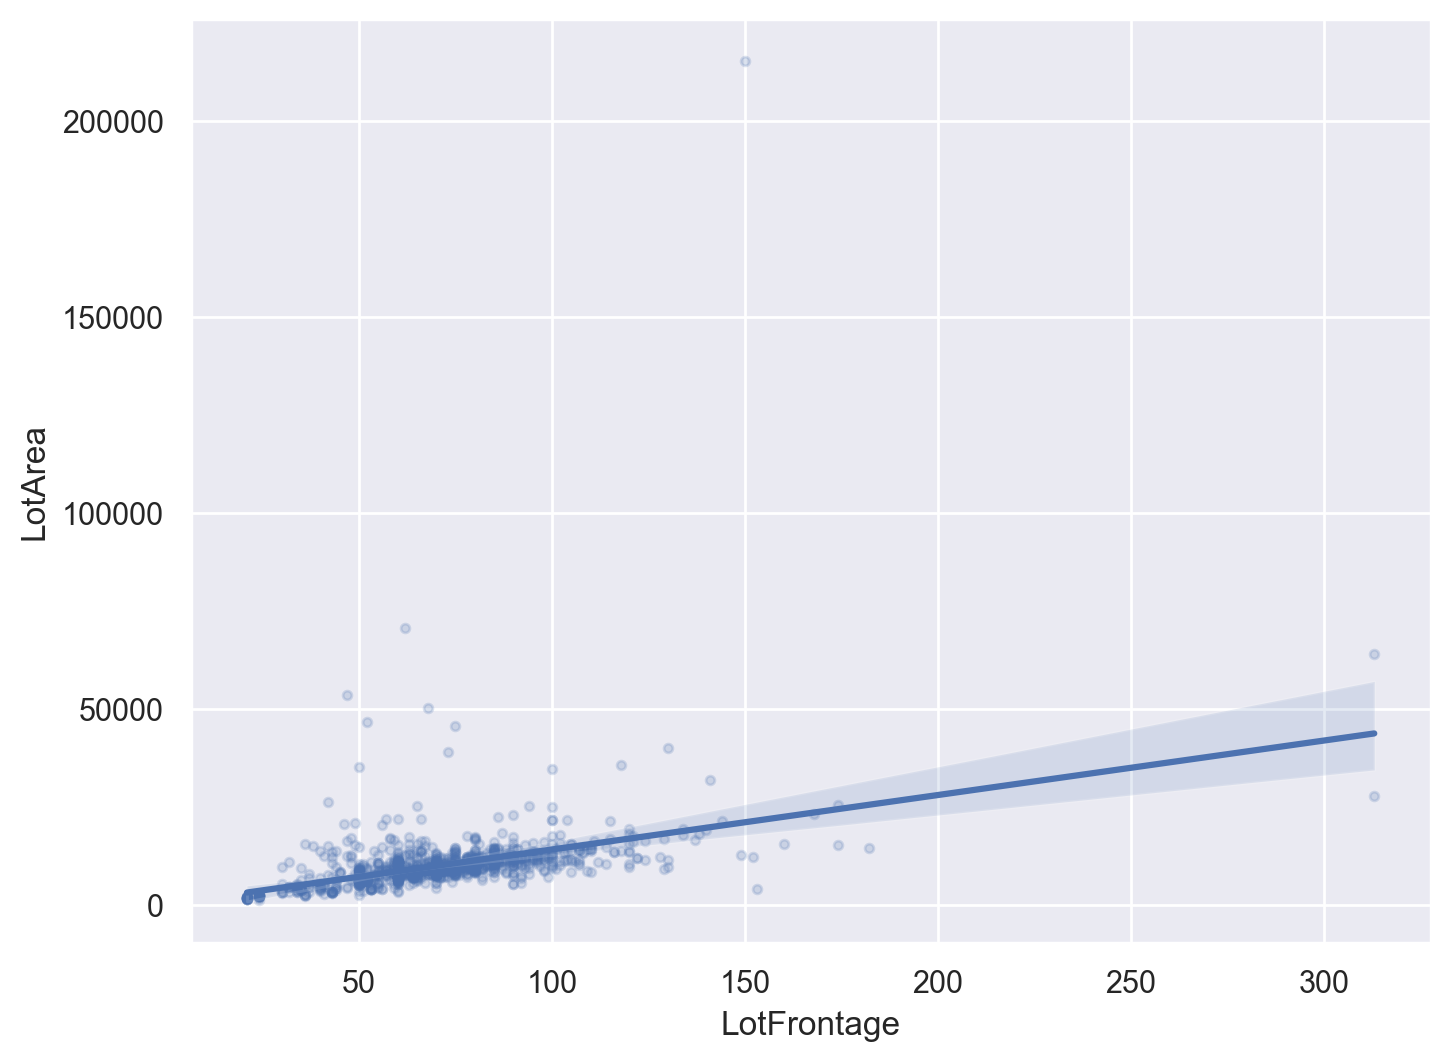

In [14]:
print(f"Correlation: {df_houses['LotFrontage'].corr(df_houses['LotArea']):.2f}")
plt.figure(figsize=(8,6))
sns.regplot(x=df_houses['LotFrontage'], y=df_houses['LotArea'],scatter_kws={'s':10, 'alpha':0.2});

The chart shows that there is indeed some correlation, despite the outliers, although it is not excessively high (0.43). For the sake of simplicity, and since the difference will not be too substantial (and we are not competing), the median can be used to impute the missing values.

In [15]:
df_houses['LotFrontage'] = df_houses['LotFrontage'].fillna(df_houses['LotFrontage'].median())

<div class="alert alert-block alert-danger">

<i class="fa fa-info-circle" aria-hidden="true"></i> Strictly speaking, we are introducing a **data leakage** issue here. Since we intend to impute the median of the entire attribute before performing the train/test split, the preparation/learning pipeline would be using instances that should only be used at prediction and reporting time.
</div>

The next variable to examine is `GarageYrBlt`. The presence of a value is informative, as it is associated with the existence of a garage. Since this information is already provided by two other variables, `GarageFinish` and `GarageType`, it is advisable to distort the data as little as possible. In this case, we can impute the minimum value of the column.

In [16]:
df_houses['GarageYrBlt'] = df_houses['GarageYrBlt'].fillna(df_houses['GarageYrBlt'].min())

<div class="alert alert-block alert-danger">

<i class="fa fa-info-circle" aria-hidden="true"></i> Strictly speaking, this also applies here (for computing the minimum).
</div>

The last variable, `MasVnrArea`, corresponds to the masonry veneer area. A look at the missing values alongside the `MasVnrType` column provides information about this feature.

In [17]:
df_houses[df_houses['MasVnrArea'].isna()][['MasVnrArea','MasVnrType']]

,MasVnrArea,MasVnrType
Id,,
235,NaN,None
530,NaN,None
651,NaN,None
937,NaN,None
974,NaN,None
978,NaN,None
1244,NaN,None
1279,NaN,None


It appears that the missing values correspond to the absence of masonry. Therefore, the value 0 will be imputed.

In [18]:
df_houses['MasVnrArea'] = df_houses['MasVnrArea'].fillna(0)

<div class="alert alert-block alert-warning">
    
<i class="fa fa-exclamation-circle" aria-hidden="true"></i>
__Important__: It is worth remembering that we have worked with the complete dataset because we have precise information about the values each variable can take. In practice, these transformations and imputations should be performed in a *pipeline* on the training set in order to properly handle new data.
<br><br>


With this caveat in mind, considering that we assume training and test data come from the same distribution, that the impact of the data leakage is minimal, and also **with the intention of simplifying the workflow**, we will impute the values for the two columns that were left for later.
</div>

In [19]:
df_houses['LotFrontage'] = df_houses['LotFrontage'].fillna(df_houses['LotFrontage'].median())
df_houses['GarageYrBlt'] = df_houses['GarageYrBlt'].fillna(df_houses['GarageYrBlt'].min())

<div align="right">
<a href="#indice"><font size=5 color="#00586D"><i class="fa fa-arrow-circle-up" aria-hidden="true"></i></font></a>
</div>

---

<a id="section3"></a>
## <font color="#00586D"> 3. Preliminary Exploration</font>
<br>


Since the ultimate goal of this project is prediction, and the number of variables is high, the exploration should focus on the target variable. Below is the distribution of the `SalePrice` column. The distribution is left-skewed, and there are extreme values. It may be necessary to take this into account when building the models.

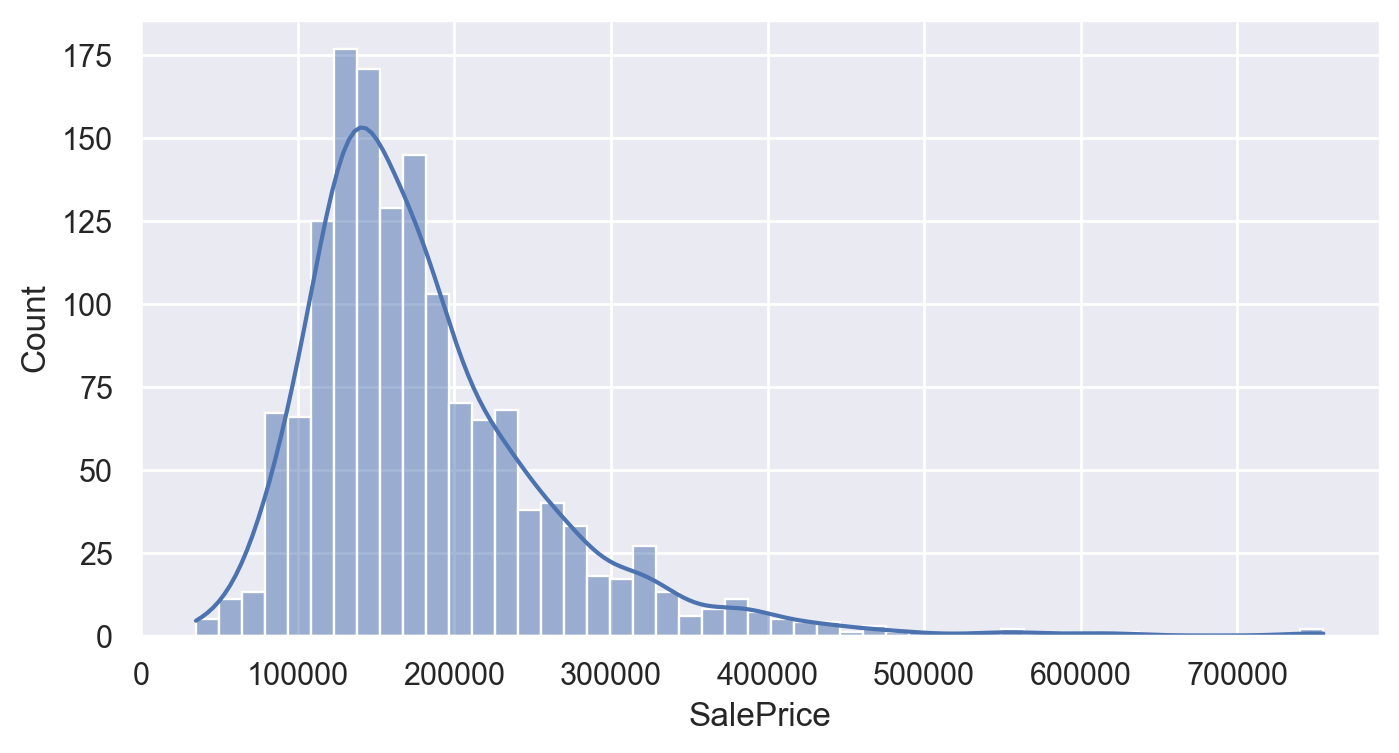

In [20]:
plt.figure(figsize=(8,4))
sns.histplot(x=df_houses['SalePrice'], kde=True);

---

### <font color="#00586D">Exploration of Variables Related to Housing Price</font>
<br>

Given the large number of variables and the project objective, we will initially focus on those most correlated (positively or negatively) with the sale price `SalePrice`. First, the numerical and ordinal features will be explored.

In [21]:
df_houses.select_dtypes(include=np.number).corr()['SalePrice'].nlargest(20)
#df_houses.select_dtypes(include=np.number).corr()['SalePrice'].nsmallest(20)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
ExterQual       0.682639
KitchenQual     0.659600
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
BsmtQual        0.585207
FullBath        0.560664
GarageFinish    0.549247
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
FireplaceQu     0.520438
GarageYrBlt     0.518287
YearRemodAdd    0.507101
MasVnrArea      0.472614
Fireplaces      0.466929
HeatingQC       0.427649
Name: SalePrice, dtype: float64

We will consider, for example, the top 20 features with the highest correlation (positive or negative) using the absolute value.

In [22]:
relevant_num_feat = (df_houses.select_dtypes(include=np.number).corr()['SalePrice']).map(np.abs).nlargest(20)
relevant_num_feat

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
ExterQual       0.682639
KitchenQual     0.659600
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
BsmtQual        0.585207
FullBath        0.560664
GarageFinish    0.549247
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
FireplaceQu     0.520438
GarageYrBlt     0.518287
YearRemodAdd    0.507101
MasVnrArea      0.472614
Fireplaces      0.466929
HeatingQC       0.427649
Name: SalePrice, dtype: float64

It can be observed that the strongest correlations are positive, and that the correlation exceeds 0.5 in some cases. Their names (excluding `SalePrice`) will be stored for *possible* later use.

In [23]:
import pickle

relevant_num_feat = relevant_num_feat[relevant_num_feat>0.5].index.to_list()[1:]#  Excludes `SalePrice`
print(relevant_num_feat)

# Save the information
with open('data/relevant.pickle', 'wb') as file:
    pickle.dump(relevant_num_feat, file)

['OverallQual', 'GrLivArea', 'ExterQual', 'KitchenQual', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'BsmtQual', 'FullBath', 'GarageFinish', 'TotRmsAbvGrd', 'YearBuilt', 'FireplaceQu', 'GarageYrBlt', 'YearRemodAdd']


Next, the top 5 features from `relevant_num_feat` (the most correlated) and `SalePrice` are explored using a `PairPlot` figure.

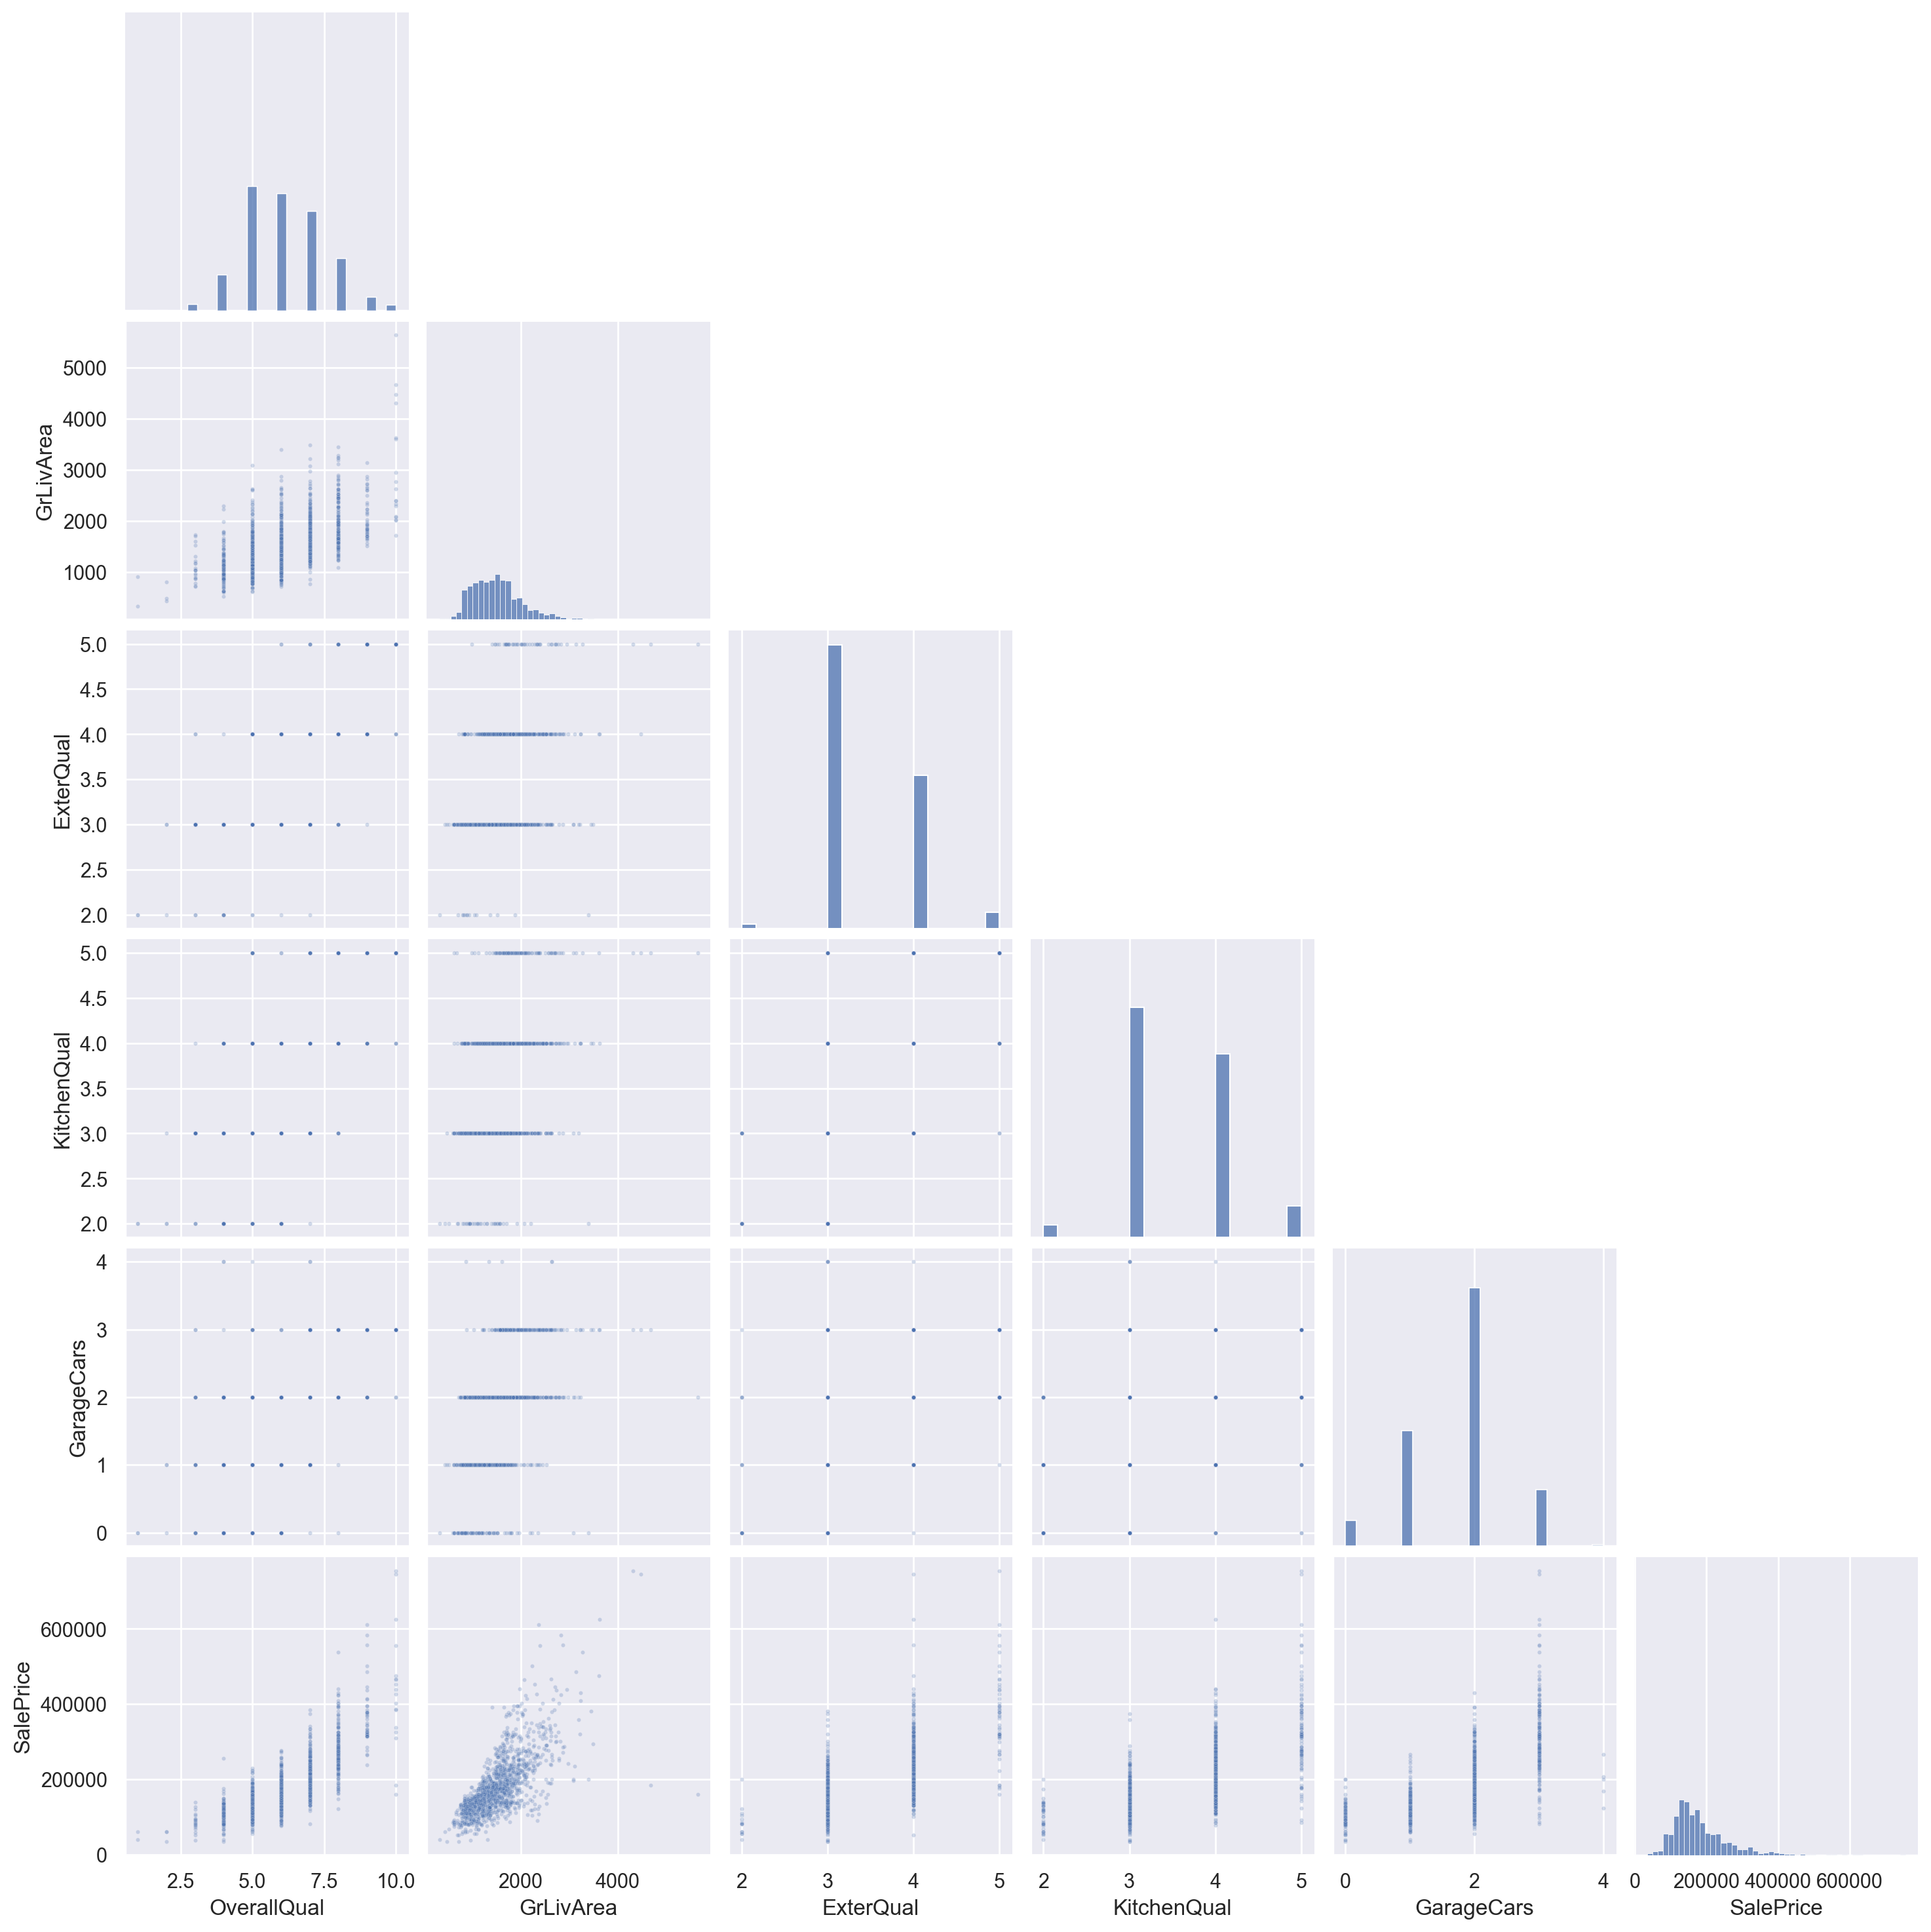

In [24]:
sns.pairplot(df_houses[relevant_num_feat[0:5]+['SalePrice']], corner=True,  plot_kws={'s':5,'alpha':0.25});

The chart reveals several details beyond the previously obtained correlations. One is that the distribution of `GrLivArea` values (the above-ground living area) is also slightly skewed. Additionally, the sale price variance increases as the value of other variables such as `OverallQual` or `GarageCars` increases (*heteroscedasticity*).

The relationship between `OverallQual` and `SalePrice` *appears to be potentially non-linear*. The following figure shows this relationship, as well as the relationship of `OverallQual` with the logarithm of `SalePrice`.

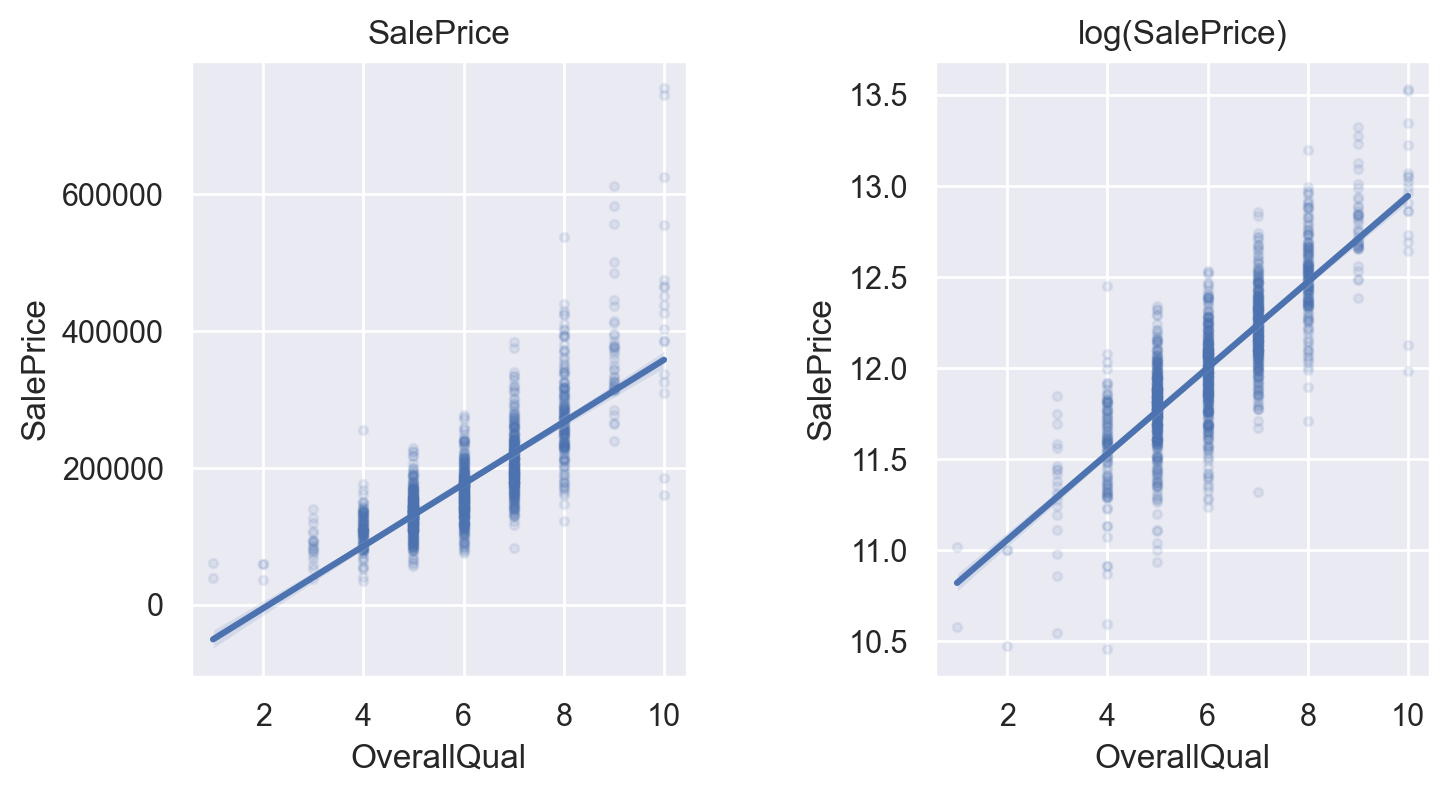

In [25]:
f, axes_grid = plt.subplots(1,2, figsize=(8,4))
sns.regplot(x=df_houses['OverallQual'], y=df_houses['SalePrice'], scatter_kws={'s':10, 'alpha':0.1}, ax = axes_grid[0]);
sns.regplot(x=df_houses['OverallQual'], y=np.log(df_houses['SalePrice']), scatter_kws={'s':10, 'alpha':0.1}, ax = axes_grid[1]);
axes_grid[0].set_title('SalePrice')
axes_grid[1].set_title('log(SalePrice)')
plt.subplots_adjust( wspace=0.5)

It appears that the second chart does indeed represent the relationship better, although *the difference is very subtle*.

Regarding categorical variables, the analysis can be more laborious. Below, a box plot is drawn for each categorical variable in order to identify any relationship with the price. To see the trends more clearly, the categories can be sorted by the median.

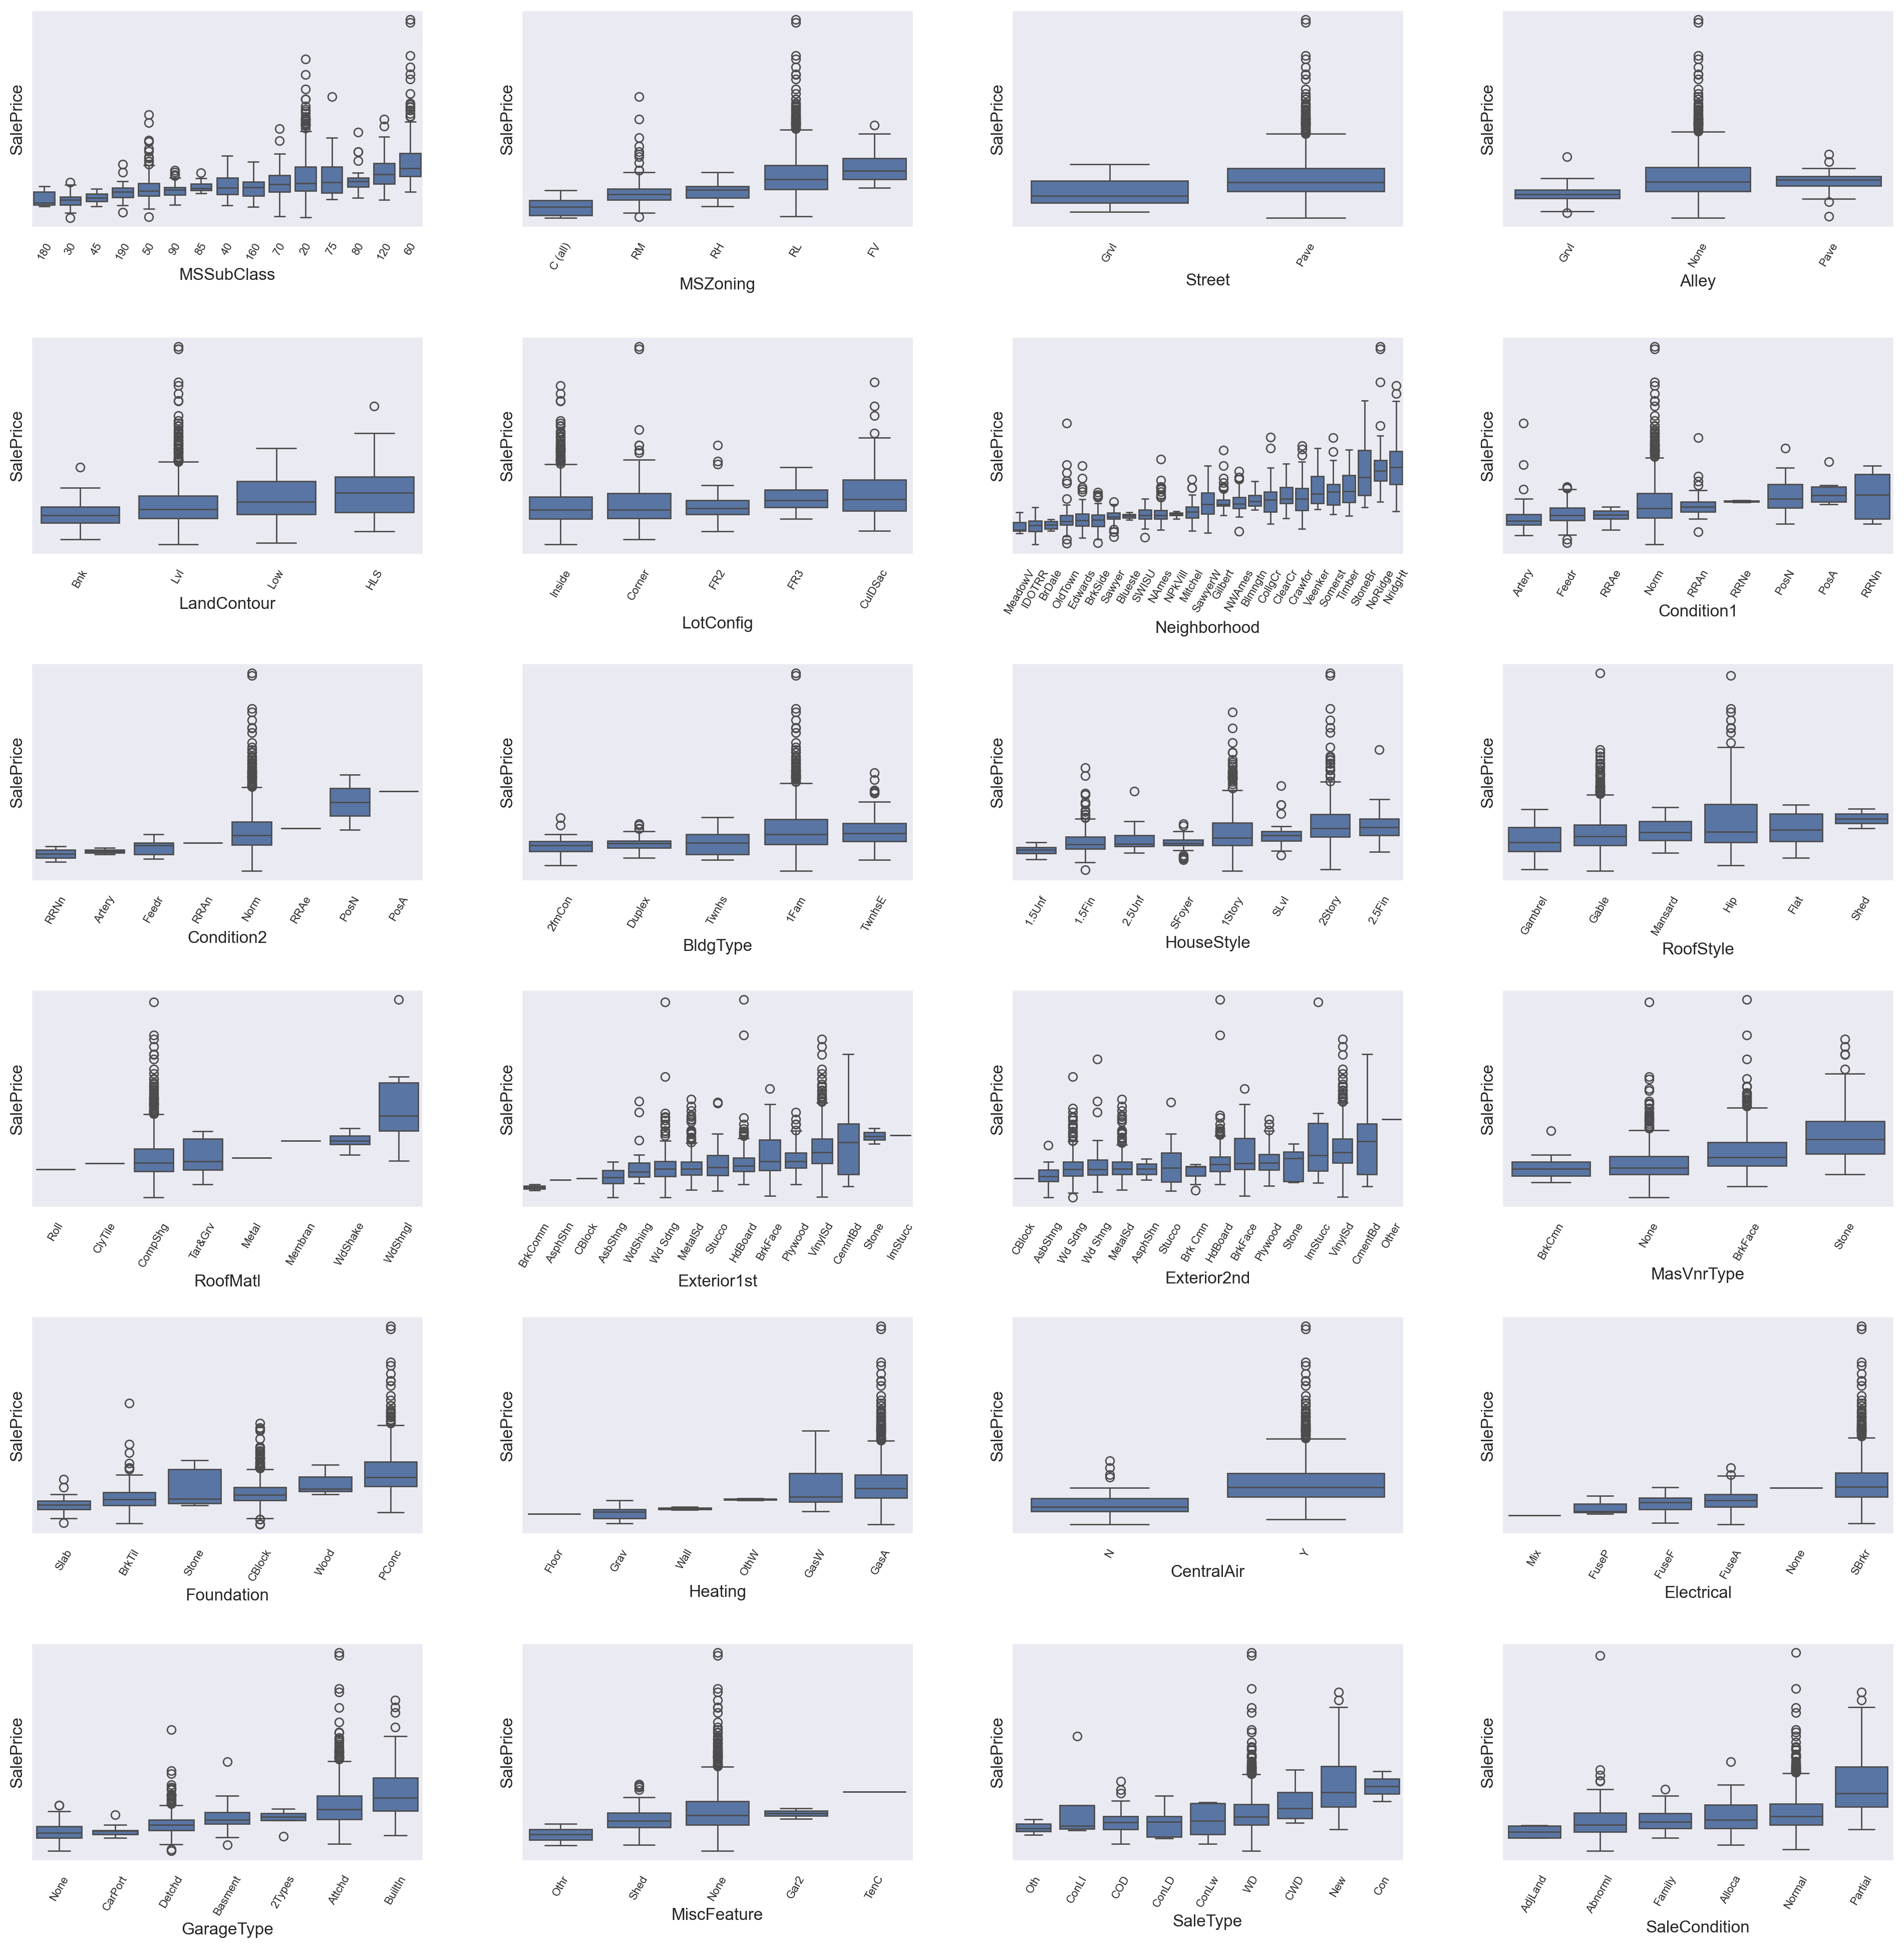

In [26]:
f, axes_grid = plt.subplots(6,4, figsize=(24,24))

for column,ax in zip(discrete,axes_grid.flatten()):
    order = df_houses.groupby(column)['SalePrice'].median().sort_values().index.to_list()
    sns.boxplot(data=df_houses, x=column, y='SalePrice', order=order, ax=ax)
    ax.tick_params(axis='x', rotation=60, labelsize=8)
    ax.set_yticks([]) 
    
plt.subplots_adjust(hspace=0.5, wspace=0.25)

Although the variability makes it difficult to clearly discern the trends, the influence of the discrete variable on price is clearly visible for features such as `Neighborhood`, `LandContour`, `MSZoning`, and others. In other cases, such as `SaleCondition`, no difference is observed except for one category (`Partial`).

Another way to assess the influence of discrete variables on price — also related to how they are encoded in the learning model — is to perform *One Hot* encoding (using `pd.get_dummies`) and calculate the correlation with `SalePrice`.



In [27]:
pd.concat([pd.get_dummies(df_houses[discrete]), df_houses['SalePrice']], axis=1).corr()['SalePrice'].nlargest(20)

SalePrice                1.000000
Foundation_PConc         0.497734
Neighborhood_NridgHt     0.402149
SaleType_New             0.357509
SaleCondition_Partial    0.352060
GarageType_Attchd        0.335961
MasVnrType_Stone         0.330476
Neighborhood_NoRidge     0.330424
Exterior2nd_VinylSd      0.306389
Exterior1st_VinylSd      0.305009
CentralAir_Y             0.251328
MSZoning_RL              0.245063
HouseStyle_2Story        0.242880
Electrical_SBrkr         0.241896
RoofStyle_Hip            0.235897
GarageType_BuiltIn       0.235449
Neighborhood_StoneBr     0.215363
MasVnrType_BrkFace       0.198191
RoofMatl_WdShngl         0.169324
LotConfig_CulDSac        0.141818
Name: SalePrice, dtype: float64

In this case, the positive correlation corresponds to certain values, such as the concrete foundation (`Foundation_PConc`), a specific neighborhood (`Neighborhood_NridgHt`), or the sale type (`SaleType_New`). However, these correlations are not excessively strong. The negatively correlated features can also be obtained.

In [28]:
pd.concat([pd.get_dummies(df_houses[discrete]), df_houses['SalePrice']], axis=1).corr()['SalePrice'].nsmallest(20)

MasVnrType_None        -0.367456
GarageType_Detchd      -0.354141
Foundation_CBlock      -0.343263
MSZoning_RM            -0.288065
CentralAir_N           -0.251328
SaleType_WD            -0.242598
GarageType_None        -0.236832
RoofStyle_Gable        -0.224744
Foundation_BrkTil      -0.204117
Electrical_FuseA       -0.193978
Neighborhood_OldTown   -0.192189
Neighborhood_NAmes     -0.188513
Neighborhood_Edwards   -0.179949
Exterior1st_MetalSd    -0.167068
Neighborhood_IDOTRR    -0.164056
HouseStyle_1.5Fin      -0.163466
Exterior2nd_MetalSd    -0.162389
Exterior2nd_Wd Sdng    -0.161800
Exterior1st_Wd Sdng    -0.158619
SaleCondition_Normal   -0.153990
Name: SalePrice, dtype: float64

The absence of masonry (`MasVnrType_None`), a detached garage (`GarageType_Detchd`), or certain neighborhoods negatively affect the housing price.

Since the number of binary variables is very large relative to the dataset, and there is a risk of overfitting, we will keep only the most relevant ones (positively or negatively) and store them in `relevant_dum_feat` in case this information is needed in later stages.

In [29]:
relevant_dum_feat = (pd.concat([pd.get_dummies(df_houses[discrete]), df_houses['SalePrice']], axis=1)
                   .corr()['SalePrice']
                   .apply(np.abs)
                   .nlargest(20)).index.to_list()[1:]

print(relevant_dum_feat)

# Save the information
with open('data/relevant_oh.pickle', 'wb') as file:
    pickle.dump(relevant_dum_feat, file)

['Foundation_PConc', 'Neighborhood_NridgHt', 'MasVnrType_None', 'SaleType_New', 'GarageType_Detchd', 'SaleCondition_Partial', 'Foundation_CBlock', 'GarageType_Attchd', 'MasVnrType_Stone', 'Neighborhood_NoRidge', 'Exterior2nd_VinylSd', 'Exterior1st_VinylSd', 'MSZoning_RM', 'CentralAir_Y', 'CentralAir_N', 'MSZoning_RL', 'HouseStyle_2Story', 'SaleType_WD', 'Electrical_SBrkr']


Finally, a dataset will be created. The only transformation needed is for the discrete variables, which require a *One Hot* transformation. The resulting dataset will be saved to the file `data/houses_prep.csv`.

In [30]:
data = pd.concat([df_houses[numerical+ordinal], pd.get_dummies(df_houses[discrete])], axis=1).copy()
data.to_csv('data/houses_prep.csv')

<div align="right">
<a href="#indice"><font size=5 color="#00586D"><i class="fa fa-arrow-circle-up" aria-hidden="true"></i></font></a>
</div>

---

<div align="right">
<a href="#indice"><font size=6 color="#00586D"><i class="fa fa-coffee" aria-hidden="true"></i></font></a>
</div>